# Домашнє завдання: Інтерактивні візуалізації з Plotly

## Опис завдання
У цьому домашньому завданні ви будете створювати інтерактивні візуалізації з допомогою бібліотеки Plotly. Ви дізнаєтесь різницю між Plotly Express (швидкі графіки) та Graph Objects (повний контроль), та створите інтерактивний дашборд.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---

🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Завантаження даних
df = pd.read_csv('sample_data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# Для plotly краще не встановлювати datetime як індекс
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.day_name()

# Додаємо назви кварталів в окрему колонку
quarter_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
df['quarter_name'] = df['season'].map(quarter_map)

## Завдання 1: Базовий інтерактивний лінійний графік (Plotly Express)

**Завдання:**
Створіть інтерактивний лінійний графік динаміки оренди за часом (рівень деталізації - як в даних) з можливістю zoom та hover.

Дайте відповіді на питання.
**Питання для інтерпретації:**
1. Яка перевага інтерактивного графіка над статичним?
2. Чому на графіку є "пробіли" - ділянки, де одна пряма лінія зʼєднує два "суцільних" блоки з даними? Як би ви це могли дослідити на статичному графіку?


In [2]:
fig = px.line(df, x='datetime', y='count',
              title='Інтерактивний графік оренд велосипедів')
fig.update_layout(hovermode='x unified')
fig.show()

**Відповідь:**
1.Інтерактивний графік дозволяє наближати (zoom) конкретні ділянки для детальнішого розгляду, не втрачаючи загальної картини на решті графіка. При наведенні курсора (hover) можна побачити точні значення в кожній точці.
Це є дуже помічним для такого щільного, шумного графіка.

Статичний графік у даному випадку не дав би нам інформативності так, як злився б у суцільну синю масу.


---


2.Ми бачимо "пробіли" тому, що в датасеті дані присутні лише за 19 днів, а решта - відсутні. Оскільки лінійний графік завжди з'єднує сусідні за порядком точки прямою лінією, а між останнім днем одного місяця і першим днем наступного немає жодних проміжних записів, тому Plotly малює пряму через увесь порожній проміжок.

На статичному графіку ми можемо це перевірити за допомогою коду - df['datetime'].dt.day.unique(), це покаже, які дати присутні в датасеті.

## Завдання 2: Scatter plot з додатковими даними (Plotly Express)

**Завдання:**
Створіть scatter plot кількості орендованих велосипедів випадковими користувачами vs кількості орендованих велосипедів зареєстрованими користувачами. Розмір точок встановіть за сумарною кількістю велосипедів, які були взяті в оренду, а колір - за сезоном(кварталом). В hover_data - додайте деталі, які допоможуть вам в подальшому аналізі.

Дослідіть графік. Зверніть увагу, що ви можете вмикати і вимикати окремі квартали, якщо будете клікати на колір кварталу в легенді графіку.

**Дайте відповідь на питання.**
- Як ви проінтерпретуєте роздвоєність цього графіку (дві явні лінії)? Що це означає?
- Які висновки для компанії, які дає велосипеди в оренду, ви можете зробити з цього графіку? 3 основних висновки.

In [3]:
fig = px.scatter(df,
                 x='registered',
                 y='casual',
                 size='count',
                 color='quarter_name',
                 #hover_data=['date', 'month'],
                 title='Аналіз ефективності орендованих велосипедів за типом користувача',
                 labels={'conversion': 'Конверсія (%)'})
fig.update_layout(height=600)
fig.show()

**Відповідь:**
1.Роздвоєність цього графіку ми маємо через те, що є дві різні групи користувачів: перша — зареєстровані користувачі (точки розтягнуті вправо вздовж осі X, registered), і друга — випадкові (точки витягнуті вгору вздовж осі Y, casual). Це означає, що в межах однієї години оренди зазвичай переважає або один тип користувачів, або інший, а не обидва одночасно в рівних пропорціях.

2.Висновки для компанії:
*   З огладу на графік ми бачимо, що кількість оренд є більшою середьзарестрованих юзерів, більшість точок витягнуті вздовж осі X далі, ніж вздовж осі Y.
*   Зареєстровані користувачі активно орендують велосипеди протягом усіх сезонів (Q1-Q4) досить рівномірно, тоді як активність сезонних зростає навесні й влітку (Q2-Q3) і різко падає взимку (Q1).
*   Найбільші за розміром точки (найбільша кількість оренд загалом) зосереджені там, де багато зареєстрованих і помірна кількість випадкових користувачів. Це означає, що основний прибуток компанії тримається саме на постійних клієнтах, а не на випадкових. З огладу на це, компанії варто зосередитись на утриманні зареєстрованих користувачів, а сезонний бум випадкових навесні та влітку можна використати для акцій, які будуть заохочувати їх реєструватися.








## Завдання 3: Порівняння Plotly Express vs Graph Objects

**Завдання:**
Створіть лінійний графік помісячної динаміки оренди (кількість оренд) велосипедів двома способами - з Plotly Express та з Graph Objects.

**Дайте відповіді на питання.**
1. Як ви розумієте основну різницю між цими двома підходами?
2. Коли краще використовувати Plotly Express?
3. Коли потрібен Graph Objects?


In [4]:
monthly = df.groupby('month')['count'].mean().reset_index()

fig = px.line(monthly, x='month', y='count',
              title='Інтерактивний графік оренд велосипедів по місяцях',
              markers= (True, dict(size=10)))

fig.update_layout(
    hovermode='x unified',
    template='plotly_white',
    height=500,
    xaxis_title='Місяць',
    yaxis_title='Кількість оренд',
    xaxis=dict(dtick=1)  # показувати тик на кожне ціле значення (1,2,3,...,12)
)

fig.show()

In [5]:

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=monthly['month'],
        y=monthly['count'],
        mode='lines+markers',
        marker=dict(size=10)
    )
)

fig.update_layout(
    title='Інтерактивний графік оренд велосипедів по місяцях',
    hovermode='x unified',
    template='plotly_white',
    height=500,
    xaxis_title='Місяць',
    yaxis_title='Кількість оренд',
    xaxis=dict(dtick=1))

fig.show()

**Відповідь:**
1.*Plotly Express* — це високорівнева обгортка над Graph Objects. Вона має у собі під капотом певні налаштування для побудови графіків автоматично, тому це легко зробити майже за 1 рядок коду.

*Graph* Objects* — низькорівневий інтерфейс, де кожен елемент графіка треба налаштовувати вручну, разом з тим це дає повний контроль над кожною деталлю.

2.*Plotly Express* краще використовувати, коли потрібно швидко побудувати стандартний графік для дослідження даних, без глибокої кастомізації.

3.*Graph Objects* краще використовувати, коли треба побудувати щось складніше за стандартний графік. Наприклад, комбінувати кілька різних типів графіків на одній фігурі, робити дашборди з кількома підграфіками, чи детально налаштовувати кожен елемент.

## Завдання 4 (Опціональне): Дашборд з make_subplots (Graph Objects)

**Завдання:**
Створіть дашборд з 4 різними графіками в одній фігурі:
- Bar chart - середні значення загальної кількості оренд велосипедів за сезонами(кварталами)
- Pie chart - відсоткове співвідношення погодних умов в даних
- Line chart - середнє значення загальної кількості оренд велосипедів за годинами протягом доби
- Scatter plot - кореляція температури vs вологість

Додайте заголовок на дашборд.

**Дайте відповідь на питання**
- На ваш погляд, яка перевага об'єднання графіків в один дашборд?

In [6]:
avg_count_by_s = df.groupby('season')['count'].mean().round(0).reset_index()
avg_count_by_s

,season,count
0,1,116.0
1,2,215.0
2,3,234.0
3,4,199.0


In [7]:
weather_q = df.groupby('weather')['count'].sum().round(3)
weather_q

,count
weather,
1,1476063
2,507160
3,102089
4,164


In [8]:
labels = ['Ясно', 'Туман', 'Легкий Дощ', 'Cильний дощ']
values = [1476063, 507160, 102089, 164]
colors = ['goldenrod', 'lightgray', 'lightcyan', 'royalblue']

In [9]:
hourly_avg = df.groupby('hour')['count'].mean().reset_index().round(0)
hourly_avg

,hour,count
0,0,55.0
1,1,34.0
2,2,23.0
3,3,12.0
4,4,6.0
5,5,20.0
6,6,76.0
7,7,213.0
8,8,363.0
9,9,222.0


In [10]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles = ('Розподіл оренд за сезоном', 'Частка записів за погодними умовами',
                    'Динаміка сереньої кількості оренд', 'Температура vs Вологість'),

specs=[
        [{'type': 'xy'}, {'type': 'domain'}],   # рядок 1: bar-графік і pie-графік
        [{'type': 'xy'}, {'type': 'xy'}]
    ]
)

#Bar chart - середні значення загальної кількості оренд велосипедів за сезонами(кварталами)
fig.add_trace(
    go.Bar(
        x = avg_count_by_s['season'],
        y = avg_count_by_s['count'],
        hovertemplate='Сезон: %{x}<br>К-ть оренд: %{y}<extra></extra>',
        name='Кількість оренд',
        showlegend=False,  # прибирає bar з легенди повністю
    ),
    row=1, col=1
)

fig.update_xaxes(
    tickvals=[1, 2, 3, 4],
    ticktext=['Q1', 'Q2', 'Q3', 'Q4'],
    dtick=1,
    row=1, col=1
)



#Pie chart - відсоткове співвідношення погодних умов в даних
fig.add_trace(
    go.Pie(
        labels=labels,
        values=[1476063, 507160, 102089, 164],
        name='Погодні умови',
        marker=dict(colors=colors), #щоб передати кольори в go.Pie(...)
        texttemplate='%{label}<br>%{percent:.2%}',
        hovertemplate='<b>%{label}</b><br>Кількість: %{value:,}<br>Частка: %{percent:.2%}<extra></extra>'
    ),
    row=1, col=2
)

fig.update_traces(textposition='outside')


#Line chart - середнє значення загальної кількості оренд велосипедів за годинами протягом доби
fig.add_trace(
    go.Scatter(
        x=hourly_avg['hour'],
        y=hourly_avg['count'],
        mode='lines+markers',
        name='Середня кількість оренд',
        showlegend=False,
        hovertemplate='Година: %{x}<br>Середня к-ть оренд: %{y:.0f}<extra></extra>'
    ),
    row=2, col=1
)

fig.update_xaxes(
    tickvals=list(range(0, 28, 4)),
    tickangle=0,  #0 = горизонтально/вертикально залежно від довжини тексту
    title_text='Час доби',
    row=2, col=1
)

fig.update_yaxes(
    title_text='Середня кількість оренд',
    row=2, col=1)


#Scatter plot - кореляція температури vs вологість
fig.add_trace(
    go.Scatter(
        x = df['temp'],
        y = df['humidity'],
        mode='markers',
        name='Температура VS Вологість',
        showlegend=False,
        marker=dict(
            color=df['season'],
            colorscale='viridis',
            colorbar=dict(
                title='Сезон',
                tickvals=[1, 2, 3, 4],
                ticktext=['Q1', 'Q2', 'Q3', 'Q4'],
                len=0.45,        # довжина colorbar відносно висоти графіка (0-1)
                y=0.20,          # позиція по вертикалі (щоб не накладалась на pie-легенду)
                x=1.02,          # трохи правіше графіка
                thickness=15     # товщина смужки (у пікселях) — робить її "тоншою/меншою"
                ),
            size=5
        ),
        customdata=df['quarter_name'],
        hovertemplate=(
            'Температура: %{x}<br>'
            'Вологість: %{y}<br>'
            'Сезон: %{customdata}<extra></extra>'
        )
    ),
    row=2, col=2
)

fig.update_xaxes(
    title_text='Температура',
    row=2, col=2)
fig.update_yaxes(
    title_text='Вологість',
    row=2, col=2)

fig.update_layout(
    template='plotly_white',
    height=800,
    width=1000
)
fig.show()

## Завдання 5 (Опціональне): 3D візуалізація

**Завдання:**
Створіть 3D scatter plot для аналізу взаємозв'язку температури, швидкості вітру та загальної кількості орендованих велосипедів. Колір встановіть за сезоном(кварталом), а розмір - за загальною кількість оренд також.

Дайте відповіді на питання.
**Питання для інтерпретації:**
1. Яку додаткову інформацію, на ваш погляд, дає 3D візуалізація?
2. Чи видно кластери в 3D просторі?
3. Чи ви можете зробити висновки з цієї візуалізації, чи вам було простіше побудувати кілька 2D?



In [11]:
fig = px.scatter_3d(df,
                     x='temp', y='windspeed', z='count',
                     color='quarter_name',
                     size='count',
                     title='3D аналіз оренди велосипедів',
                     category_orders={'quarter_name': ['Q1', 'Q2', 'Q3', 'Q4']},
                     labels={
                         'temp': 'Температура',
                         'windspeed': 'Швидкість вітру',
                         'count': 'Кількість оренд',
                         'quarter_name': 'Сезон'
                     })
fig.update_layout(height=700)
fig.show()

**Відповіді:**
1.3D-візуалізація дозволяє побачити взаємозв'язок трьох змінних на одному графіку (як комбінація 2-х факторів впливає на 3-й), 2D-графік показує зв'язок лише між двома змінними за раз.

2.Так, частково видно фіолетові точки (Q1, зима) концентруються при нижчих температурах і меншій кількості оренд, зелені (Q3, літо) — при вищих температурах і більшій кількості оренд. Проте точки накладаються і тому межі між кластерами не чіткі, треба обертати графік, щоб зміни перспективу.

3.Я вважаю, що для точного аналізу і якісних висновків кілька 2D-графіків  читати простіше. Для загальної картинки 3D-графік може бути корисніший.


## Завдання 6: Експорт та збереження інтерактивних графіків

**Завдання:**
Збережіть побудований попередній графік на plotly в формат HTML. Також змініть вручну щось на графіку (зум, виділення частини графіку) і збережіть його як статичне зображення через іконку фотоапарату у формат PNG. Завантажте файли з графіком у HTML та PNG (або посилання на них на github) разом з посиланням на цей ноутбук при здачі ДЗ.


In [12]:
pip install kaleido==0.2.1

In [13]:
fig.write_html("dashboard.html")

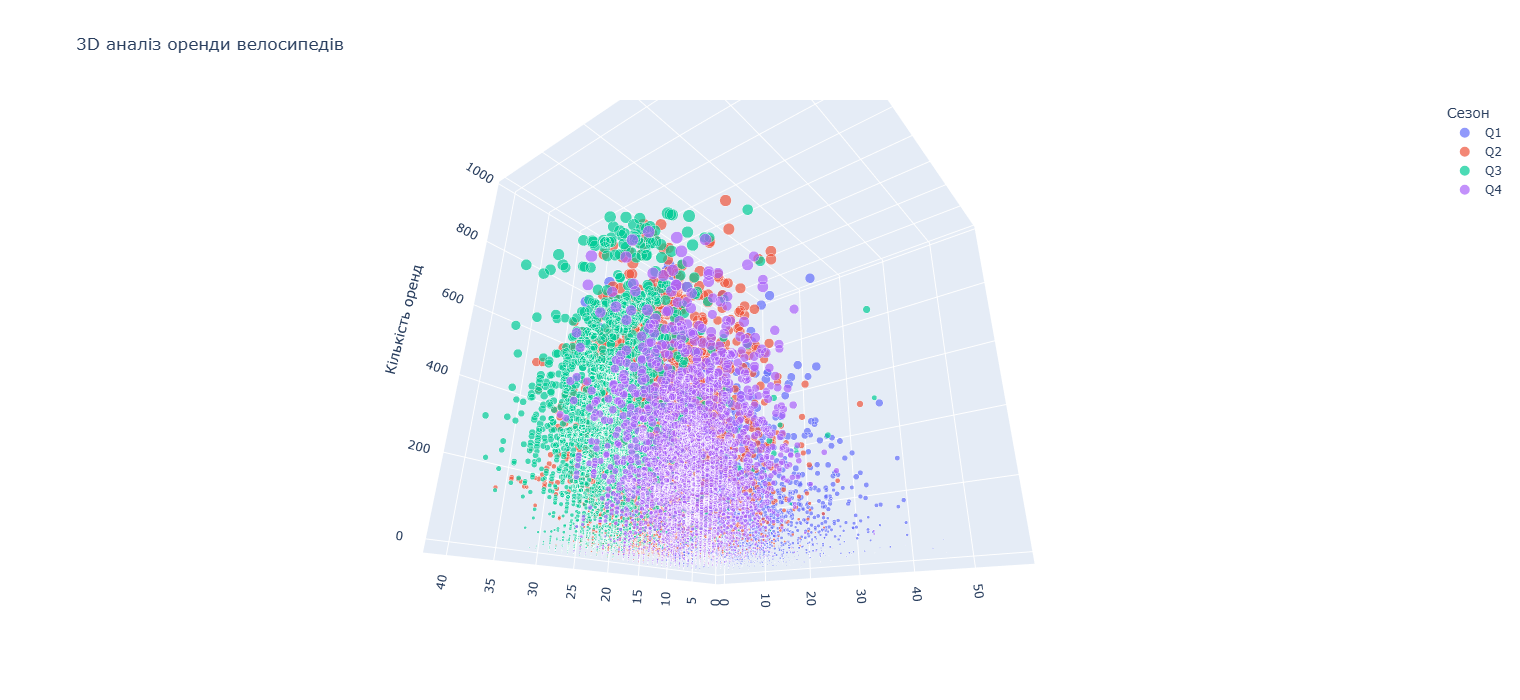